# Single-label Resnet50 with ImageNet

This notebook is for finetuning a pretrained resnet50 model on the UCM single-label dataset.  

### Imports

In [2]:
%load_ext autoreload
%autoreload 2

# Internal import
import deep_learning_land_use_classification.config as config
from deep_learning_land_use_classification.dataset import get_single_label_data
import deep_learning_land_use_classification.evaluation as evaluation
import deep_learning_land_use_classification.wanddb_helpers as wh
from deep_learning_land_use_classification.early_stopping import EarlyStopper

# External imports
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import wandb

## Getting data
The data is split into training (64%), validation (16%) and test (20%). Training is used for model training, validation is used to tune hyperparameters and pick the best model, and testing is used to assess the performance of the final model. Data is split using stratified sampling.

In [3]:
train_df, test_df, val_df, class_names, num_classes = get_single_label_data()

In [4]:
# Start a new wandb run to track this script.
run = wh.init_run(
    run_name="resnet50-single-label 02",
    task="single",
    architecture="resnet50",
    num_classes=num_classes,
    loss="CrossEntropyLoss",
    epochs=50,
    batch_size=32,
    learning_rate=1e-4,
    optimizer="AdamW",
    pretrained=True,
    pretraining_dataset="ImageNetV2",
    pretraining_source="torchvision",
    weights="IMAGENET1K_V2",
    model_name=None,
    augmentation=False,
    early_stopping=True,
    patience=6,
    min_delta=0.001
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\tomer\_netrc.
wandb: Currently logged in as: tomer-peled (sstaheli52-wageningen-university-and-research) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


### Resize, transform and normalize dataset

In [5]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # handles inconsistent sizes
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], # standard ImageNet mean
        std =[0.229, 0.224, 0.225] # standard ImageNet std
    )
])

### Get training and val dataset, as well as dataset loaders

In [6]:
class SingleLabelDataset(Dataset):
    def __init__(self, df, class_names, transform=None):
        self.df = df.reset_index(drop=True)
        self.class_names = class_names
        self.transform = transform
        self.label_to_idx = {label: i for i, label in enumerate(class_names)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["path"]).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        label = self.label_to_idx[row["label"]]
        return image, torch.tensor(label, dtype=torch.long)

train_dataset = SingleLabelDataset(train_df, class_names, transform)
val_dataset  = SingleLabelDataset(val_df, class_names, transform)

train_loader = DataLoader(train_dataset, batch_size=run.config.batch_size, shuffle=True)
val_loader  = DataLoader(val_dataset, batch_size=run.config.batch_size, shuffle=False)

### Initiate model

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print ("Using device:", device)

model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

Using device: cuda


## Define loss function
We chose to use CrossEntropyLoss for the single-label classification, combined with AdamW as the optimizer.

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [9]:
wh.log_model_summary(run, model)

### Train model

In [10]:
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [11]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

    return total_loss / len(loader)

Epoch 1/50
Train Loss: 2.3710
val Loss:  1.1239
Epoch 2/50
Train Loss: 0.6149
val Loss:  0.2273
Epoch 3/50
Train Loss: 0.1493
val Loss:  0.1075
Epoch 4/50
Train Loss: 0.0675
val Loss:  0.1053
Epoch 5/50
Train Loss: 0.0332
val Loss:  0.0645
Epoch 6/50
Train Loss: 0.0317
val Loss:  0.0827
Epoch 7/50
Train Loss: 0.0172
val Loss:  0.0400
Epoch 8/50
Train Loss: 0.0108
val Loss:  0.0727
Epoch 9/50
Train Loss: 0.0149
val Loss:  0.0930
Epoch 10/50
Train Loss: 0.0140
val Loss:  0.0789
Epoch 11/50
Train Loss: 0.0121
val Loss:  0.0530
Epoch 12/50
Train Loss: 0.0113
val Loss:  0.0551
Epoch 13/50
Train Loss: 0.0196
val Loss:  0.1025
Early stopping triggered at epoch 13. Best val loss: 0.0400
Restored best model weights.


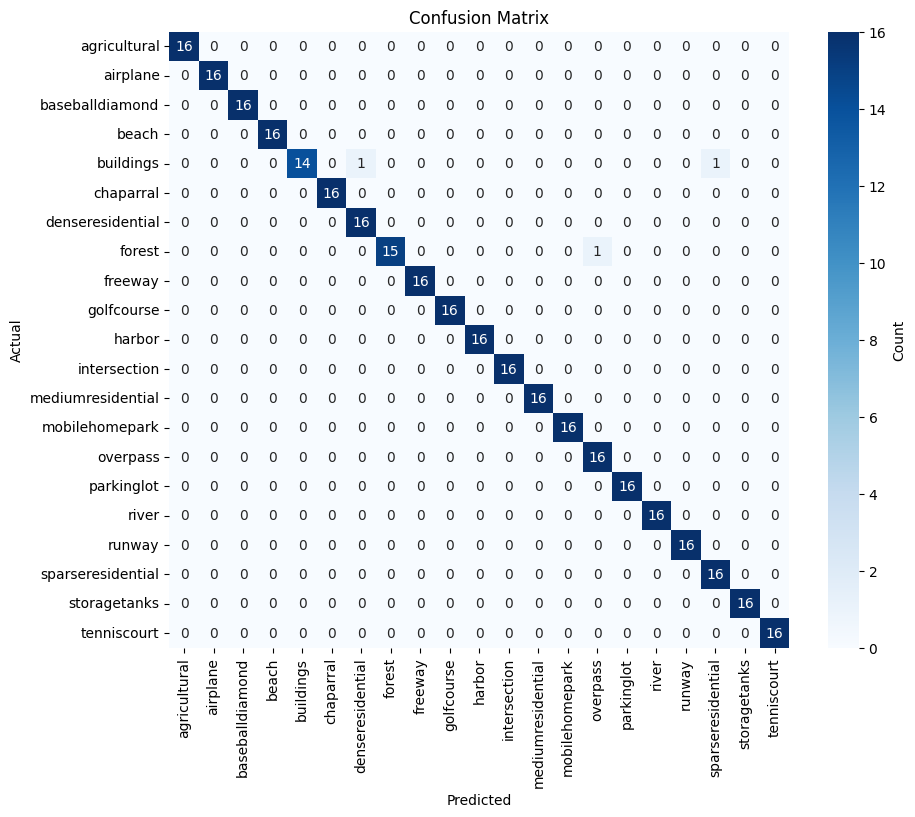

class/agricultural/f1,▁▁▁▁▁▁▁▁▁▁▁▁▁
class/agricultural/precision,▁▁▁▁▁▁▁▁▁▁▁▁▁
class/agricultural/recall,▁▁▁▁▁▁▁▁▁▁▁▁▁
class/airplane/f1,▁████████████
class/airplane/precision,▁████████████
class/airplane/recall,▁▁▁▁▁▁▁▁▁▁▁▁▁
class/baseballdiamond/f1,▁████▅███████
class/baseballdiamond/precision,▁████████████
class/baseballdiamond/recall,▁████▃███████
class/beach/f1,▁████▆███████
+59,...


In [12]:
epochs = run.config.epochs
early_stopper = EarlyStopper(patience=run.config.patience, min_delta=run.config.min_delta)

for epoch in range(epochs):
    train_loss = train(model, train_loader, optimizer, criterion)
    val_loss  = evaluate(model, val_loader, criterion)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"val Loss:  {val_loss:.4f}")
    
    precision, recall, f1, p_macro, r_macro, f1_macro = evaluation.compute_accuracy_metrics_singlelabel(
        model, val_loader, device
    )
    wh.log_epoch(run, epoch, train_loss, val_loss,
             precision, recall, f1, p_macro, r_macro, f1_macro, class_names)

    # Early stopping check
    if early_stopper.step(val_loss, model):
        print(f"Early stopping triggered at epoch {epoch+1}. Best val loss: {early_stopper.best_loss:.4f}")
        break

# Restore the weights from the best epoch
early_stopper.restore_best_weights(model)
print("Restored best model weights.")

# Plot confusion matrix
evaluation.plot_confusion_matrix(model, val_loader, class_names, device)

run.finish()

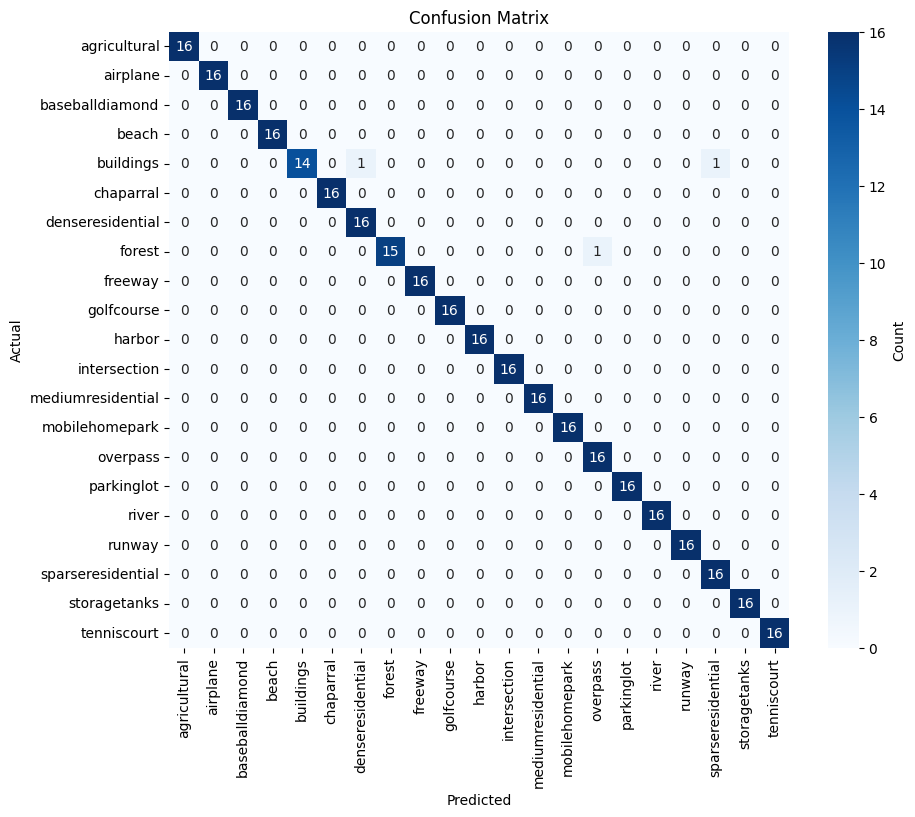

In [13]:
# Plot confusion matrix
# Ensure there is an active wandb run before plotting (cell 16 already called run.finish())
if wandb.run is None:
    wandb.init(mode="disabled", reinit=True)

evaluation.plot_confusion_matrix(model, val_loader, class_names, device)

## Test model on test dataset - Only on best model

In [14]:
test_dataset = SingleLabelDataset(test_df, class_names, transform)
test_loader = DataLoader(test_dataset, batch_size=run.config.batch_size, shuffle=False)

test_precision, test_recall, test_f1, test_p_macro, test_r_macro, test_f1_macro = evaluation.compute_accuracy_metrics_singlelabel(
    model,
    test_loader,
    device
)

print("Test Set Performance")
print(f"Precision (Macro): {test_p_macro:.4f}")
print(f"Recall (Macro):    {test_r_macro:.4f}")
print(f"F1-Score (Macro):  {test_f1_macro:.4f}")

print("\nPer-class metrics:")
for i, class_name in enumerate(class_names):
    print(
        f"{class_name:15} - "
        f"Precision: {test_precision[i]:.4f}, "
        f"Recall: {test_recall[i]:.4f}, "
        f"F1: {test_f1[i]:.4f}"
    )

Test Set Performance
Precision (Macro): 0.9886
Recall (Macro):    0.9881
F1-Score (Macro):  0.9881

Per-class metrics:
agricultural    - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
airplane        - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
baseballdiamond - Precision: 0.9524, Recall: 1.0000, F1: 0.9756
beach           - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
buildings       - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
chaparral       - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
denseresidential - Precision: 0.9500, Recall: 0.9500, F1: 0.9500
forest          - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
freeway         - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
golfcourse      - Precision: 1.0000, Recall: 0.9500, F1: 0.9744
harbor          - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
intersection    - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
mediumresidential - Precision: 0.9500, Recall: 0.9500, F1: 0.9500
mobilehomepark  - Precision: 1.0000, Recall: 1

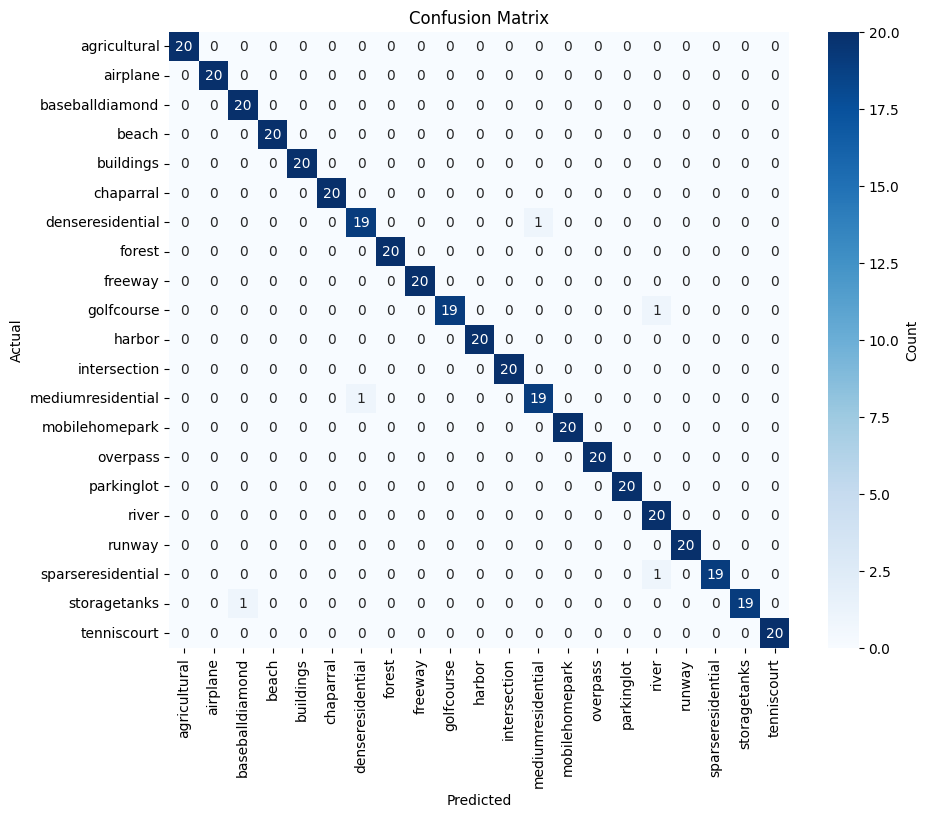

In [ ]:
# Plot confusion matrix
# Ensure there is an active wandb run before plotting (cell 16 already called run.finish())
if wandb.run is None:
    wandb.init(mode="disabled", reinit=True)

evaluation.plot_confusion_matrix(model, test_loader, class_names, device, "Test Set Confusion Matrix")